In [ ]:
!gdown 1VWfp0i294Ed10oVlLc0VDPF0-xgGZvZW
!unzip "hand gesture counting.zip" -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/hand gesture counting/class-0/Sign 0 (107).jpeg  
  inflating: /content/dataset/hand gesture counting/class-0/Sign 0 (108).jpeg  
  inflating: /content/dataset/hand gesture counting/class-0/Sign 0 (109).jpeg  
  inflating: /content/dataset/hand gesture counting/class-0/Sign 0 (11).jpeg  
  inflating: /content/dataset/hand gesture counting/class-0/Sign 0 (110).jpeg  
  inflating: /content/dataset/hand gesture counting/class-0/Sign 0 (111).jpeg  
  inflating: /content/dataset/hand gesture counting/class-0/Sign 0 (112).jpeg  
  inflating: /content/dataset/hand gesture counting/class-0/Sign 0 (113).jpeg  
  inflating: /content/dataset/hand gesture counting/class-0/Sign 0 (114).jpeg  
  inflating: /content/dataset/hand gesture counting/class-0/Sign 0 (115).jpeg  
  inflating: /content/dataset/hand gesture counting/class-0/Sign 0 (116).jpeg  
  inflating: /content/dataset/hand gesture counting/class-0/Sign 0 (11

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
results_log = []

#  Data Preprocessing & Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.1,
    horizontal_flip=True
)
# Train Generator
train_generator = train_datagen.flow_from_directory(
    '/content/dataset/hand gesture counting',
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='training',
     classes=['class-0','class-1','class-2','class-3','class-4','class-5']
)
# Validation Generator
val_generator = train_datagen.flow_from_directory(
    '/content/dataset/hand gesture counting',
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
     classes=['class-0','class-1','class-2','class-3','class-4','class-5'],
     shuffle=False
)

# Architechture

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(6, activation='softmax')
])

# compile

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# train

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)
# EVALUATE
val_loss, val_acc = model.evaluate(val_generator)

        # STORE RESULTS
results_log.append({
            "batch_size": 32,
            "epochs": 20,
            "val_accuracy": val_acc,
            "val_loss": val_loss
        })
import pandas as pd

df = pd.DataFrame(results_log)

print(df)

Found 2400 images belonging to 6 classes.
Found 600 images belonging to 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
23/75 ━━━━━━━━━━━━━━━━━━━━ 8s 170ms/step - accuracy: 0.1873 - loss: 1.8013

KeyboardInterrupt: 

In [ ]:
#confusion matrix and score
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#reset generator
val_generator.reset()

#Predictions
val_preds = model.predict(val_generator)

#Convert probabilities → class labels
y_pred = np.argmax(val_preds, axis=1)

#True labels
y_true = val_generator.classes

#Class names
class_names = ['0','1','2','3','4','5']

#Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

#Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

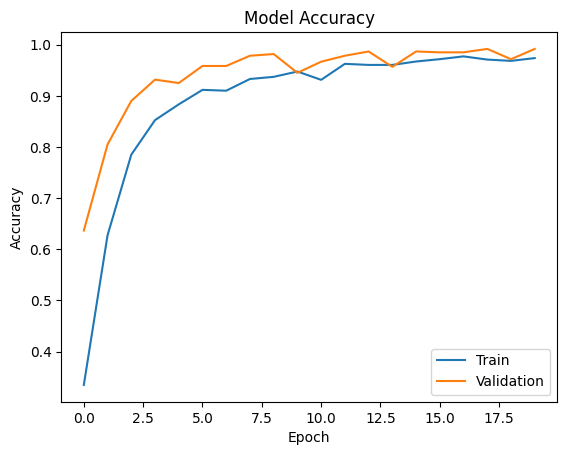

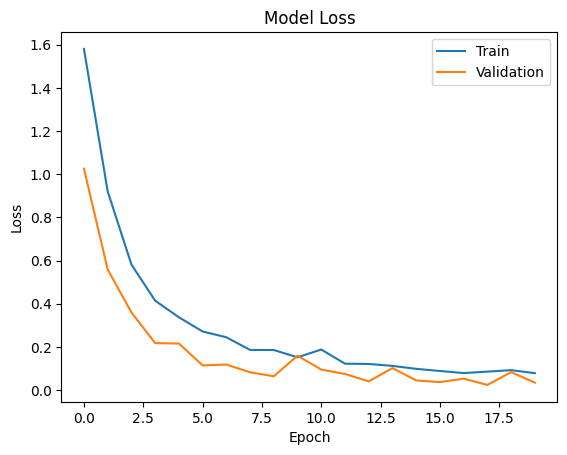

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
# # Save in HDF5 format (.h5)
# model.save("gesture_model.h5")

# # Save in new Keras format (.keras)
model.save("gesture_model.keras")

from google.colab import files

#files.download("gesture_model.h5")
files.download("gesture_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>